# Single evaluation run — visualization

Loads `aggregate_results.json` from a **single** invocation of `scripts/run_evaluation.py`.

- **Subsystems 1–3** are the three rubric blocks (4 criteria each → **12 categories** total).
- **Four pipelines** (MARS + three ablations) are compared on every chart.
- No error bars: a single run produces point scores, not distributions.

Set `AGGREGATE_PATH` below to an `aggregate_results.json`, or leave `None` to use the newest available (prefers `results/evaluation/`, falls back to `results/evaluation_runs/**/run_*/`).

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path("..").resolve()
SEARCH_ROOTS = [PROJECT_ROOT / "results", PROJECT_ROOT / "results_old"]
RUBRIC_PATH = PROJECT_ROOT / "config" / "evaluation_rubric.yaml"

AGGREGATE_PATH: str | None = None

# Preferred order of pipelines (matches run_evaluation.py)
CONDITION_ORDER = [
    "evaluation",
    "ablation_3agent",
    "ablation_1agent_rag",
    "ablation_1agent_no_rag",
]

COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


def resolve_aggregate_path(explicit: str | None) -> Path:
    if explicit:
        p = Path(explicit)
        return p if p.is_absolute() else (PROJECT_ROOT / p).resolve()
    # Prefer a single-run output at <root>/evaluation/aggregate_results.json
    for root in SEARCH_ROOTS:
        direct = root / "evaluation" / "aggregate_results.json"
        if direct.is_file():
            return direct
    # Fall back to newest aggregate under any evaluation_runs/**/run_*/
    candidates: list[Path] = []
    for root in SEARCH_ROOTS:
        runs_dir = root / "evaluation_runs"
        if runs_dir.is_dir():
            candidates.extend(runs_dir.glob("**/run_*/aggregate_results.json"))
    if candidates:
        candidates.sort(key=lambda x: x.stat().st_mtime, reverse=True)
        return candidates[0]
    searched = ", ".join(str(r) for r in SEARCH_ROOTS)
    raise FileNotFoundError(
        f"No aggregate_results.json found under: {searched}. "
        "Run run_evaluation.py, or set AGGREGATE_PATH explicitly."
    )


with open(RUBRIC_PATH, encoding="utf-8") as f:
    rubric = yaml.safe_load(f)

DIMENSION_META = rubric["dimensions"]
ALL_DIM_KEYS = list(DIMENSION_META.keys())
SYS1_KEYS = [k for k in ALL_DIM_KEYS if k.startswith("system1_")]
SYS2_KEYS = [k for k in ALL_DIM_KEYS if k.startswith("system2_")]
SYS3_KEYS = [k for k in ALL_DIM_KEYS if k.startswith("system3_")]


def short_label(dim_key: str) -> str:
    return DIMENSION_META[dim_key].get("short_name", dim_key)


def full_name(dim_key: str) -> str:
    return DIMENSION_META[dim_key].get("name", dim_key)


aggregate_path = resolve_aggregate_path(AGGREGATE_PATH)
print("Using:", aggregate_path)

with open(aggregate_path, encoding="utf-8") as f:
    aggregate = json.load(f)

conditions = aggregate.get("aggregate_scores") or {}
ranks = aggregate.get("avg_ranks") or {}
per_query = aggregate.get("per_query") or []
print("judge:", aggregate.get("judge_model"), "| queries:", aggregate.get("num_queries"))


def condition_label(ck: str) -> str:
    block = conditions.get(ck) or {}
    return block.get("label", ck)


def dim_score(ck: str, dim_key: str) -> float | None:
    block = conditions.get(ck) or {}
    v = block.get(dim_key)
    if isinstance(v, (int, float)):
        return float(v)
    return None


present_keys = [ck for ck in CONDITION_ORDER if ck in conditions]
if not present_keys:
    present_keys = list(conditions.keys())

labels_ordered = [condition_label(ck) for ck in present_keys]
colors_ordered = [COLORS[i % len(COLORS)] for i in range(len(present_keys))]
print("Pipelines:", labels_ordered)

Using: /Users/tarjeihage/Downloads/MARS_ablation3_cursorMoveGraphGeneration/results_old/evaluation_runs/20260414_174826/run_03/aggregate_results.json
judge: gpt-4.1 | queries: 1
Pipelines: ['MARS (Full Pipeline)', '3-Agent Sequential (No RAG/KG)', '1-Agent + RAG/KG', '1-Agent (No RAG/KG)']


In [3]:
# Weighted average overview
rows = []
for ck in present_keys:
    block = conditions.get(ck) or {}
    wt = block.get("weighted_avg")
    if not isinstance(wt, (int, float)):
        continue
    rows.append(
        {
            "condition_key": ck,
            "label": block.get("label", ck),
            "weighted_avg": float(wt),
        }
    )

df_weighted = pd.DataFrame(rows).sort_values("weighted_avg", ascending=False)
df_weighted

,condition_key,label,weighted_avg
1,ablation_3agent,3-Agent Sequential (No RAG/KG),4.83
3,ablation_1agent_no_rag,1-Agent (No RAG/KG),4.42
0,evaluation,MARS (Full Pipeline),3.92
2,ablation_1agent_rag,1-Agent + RAG/KG,3.08


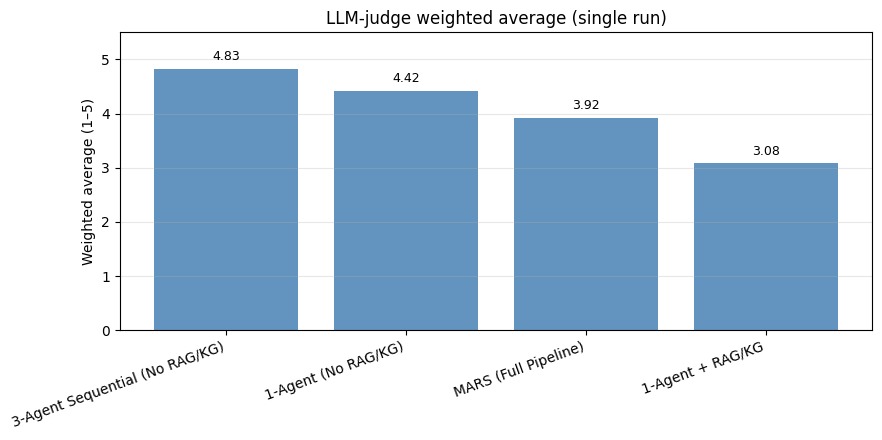

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = df_weighted["label"].tolist()
x = np.arange(len(labels))
means = df_weighted["weighted_avg"].to_numpy()
ax.bar(x, means, color="steelblue", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Weighted average (1–5)")
ax.set_title("LLM-judge weighted average (single run)")
ax.set_ylim(0, 5.5)
ax.grid(axis="y", alpha=0.3)
for xi, m in zip(x, means):
    ax.text(xi, m + 0.1, f"{m:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Spider charts — all 12 rubric categories

One radar per **pipeline**; axes are the 12 dimensions (short labels).

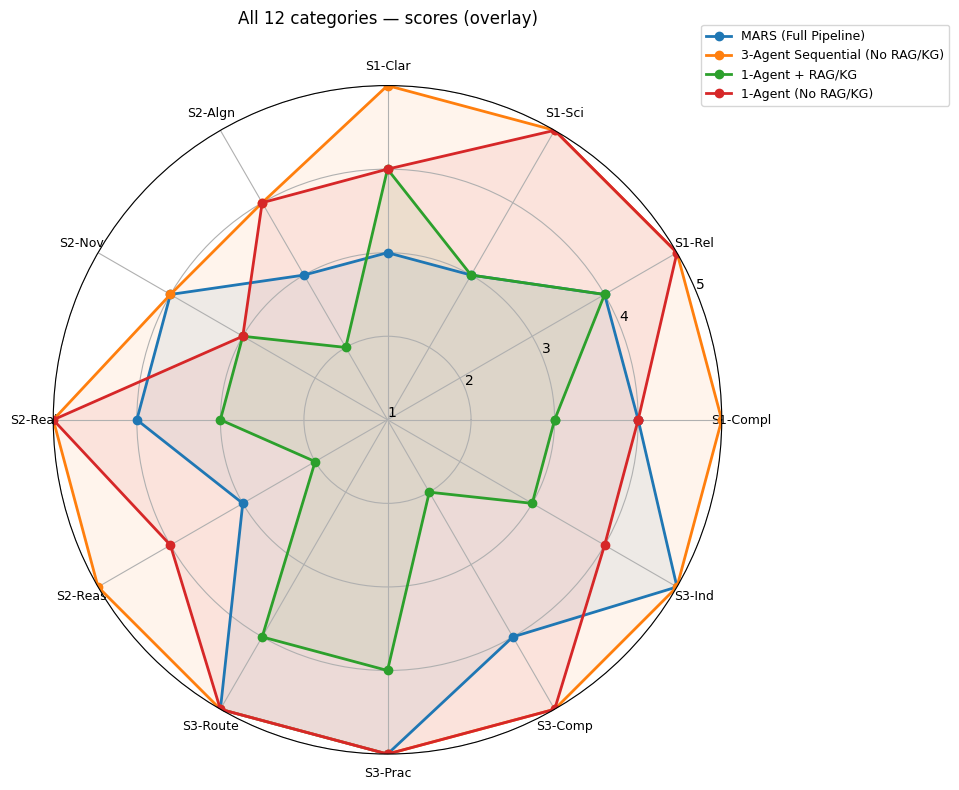

In [5]:
def radar_closed(values: list[float]) -> tuple[np.ndarray, np.ndarray]:
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    v = np.asarray(values, dtype=float)
    angles = np.concatenate([angles, angles[:1]])
    v = np.concatenate([v, v[:1]])
    return angles, v


dim_keys_12 = ALL_DIM_KEYS
tick_labels = [short_label(k) for k in dim_keys_12]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection="polar"))
for ck, lab, col in zip(present_keys, labels_ordered, colors_ordered):
    vals = [dim_score(ck, k) for k in dim_keys_12]
    if any(v is None for v in vals):
        continue
    ang, v = radar_closed([float(x) for x in vals])
    ax.plot(ang, v, "o-", linewidth=2, label=lab, color=col)
    ax.fill(ang, v, alpha=0.08, color=col)

ax.set_xticks(np.linspace(0, 2 * np.pi, len(dim_keys_12), endpoint=False))
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("All 12 categories — scores (overlay)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

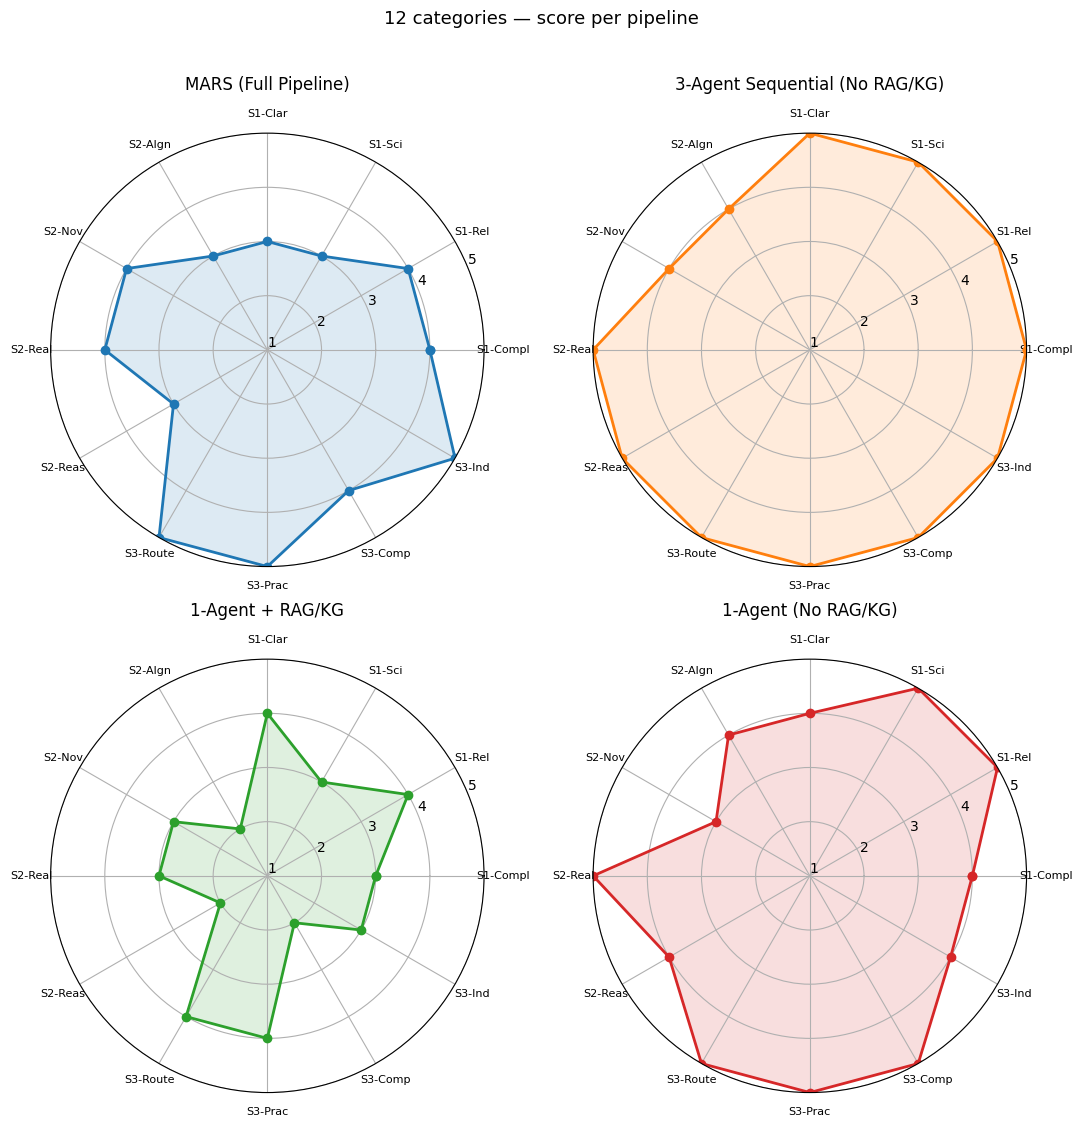

In [6]:
# Same data: one spider per pipeline (easier to read than overlay)
n_p = len(present_keys)
ncols = 2
nrows = int(np.ceil(n_p / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(11, 5.5 * nrows), subplot_kw=dict(projection="polar")
)
axes = np.atleast_2d(axes).ravel()

for idx, ck in enumerate(present_keys):
    ax = axes[idx]
    vals = [dim_score(ck, k) for k in dim_keys_12]
    if any(v is None for v in vals):
        ax.set_title(condition_label(ck) + " (missing data)")
        continue
    ang, v = radar_closed([float(x) for x in vals])
    col = colors_ordered[idx]
    ax.plot(ang, v, "o-", linewidth=2, color=col)
    ax.fill(ang, v, alpha=0.15, color=col)
    ax.set_xticks(np.linspace(0, 2 * np.pi, len(dim_keys_12), endpoint=False))
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylim(1, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_title(condition_label(ck), y=1.08)

for j in range(len(present_keys), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("12 categories — score per pipeline", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Spider charts — subsystem averages

For each pipeline, **average of the four criteria** in System 1, System 2, and System 3 → **3-axis** radar.

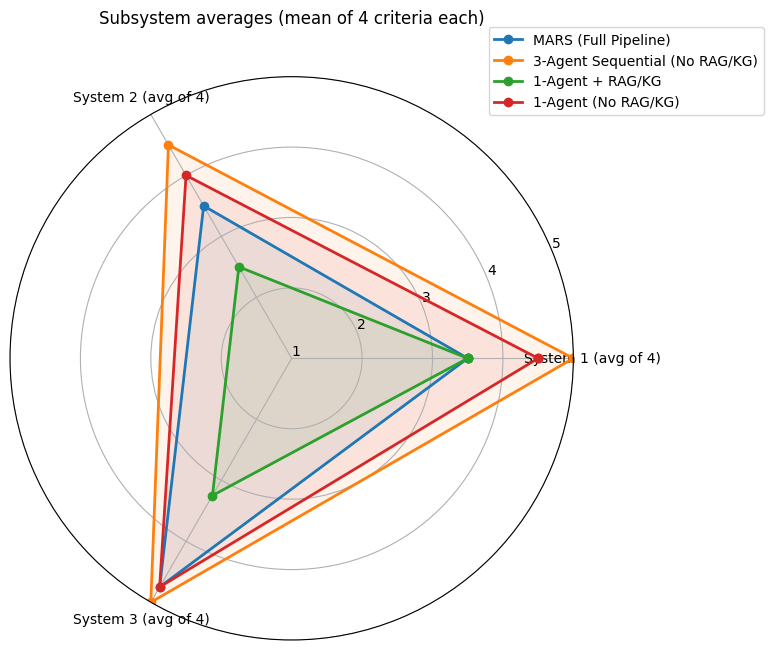

In [7]:
def subsystem_means(ck: str) -> tuple[float | None, float | None, float | None]:
    def avg(keys: list[str]) -> float | None:
        xs = [dim_score(ck, k) for k in keys]
        if any(x is None for x in xs):
            return None
        return float(np.mean(xs))

    return avg(SYS1_KEYS), avg(SYS2_KEYS), avg(SYS3_KEYS)


sys_labels = ["System 1 (avg of 4)", "System 2 (avg of 4)", "System 3 (avg of 4)"]
n_sys = 3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="polar"))
ax.set_xticks(np.linspace(0, 2 * np.pi, n_sys, endpoint=False))
ax.set_xticklabels(sys_labels, fontsize=10)

for ck, lab, col in zip(present_keys, labels_ordered, colors_ordered):
    m1, m2, m3 = subsystem_means(ck)
    if None in (m1, m2, m3):
        continue
    ang, v = radar_closed([m1, m2, m3])
    ax.plot(ang, v, "o-", linewidth=2, label=lab, color=col)
    ax.fill(ang, v, alpha=0.08, color=col)

ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("Subsystem averages (mean of 4 criteria each)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## Clustered bar chart — subsystem averages

Three **clusters** on the horizontal axis (Systems 1–3). In each cluster, **four bars** show each pipeline's **mean score** for that subsystem (average of its four rubric criteria).

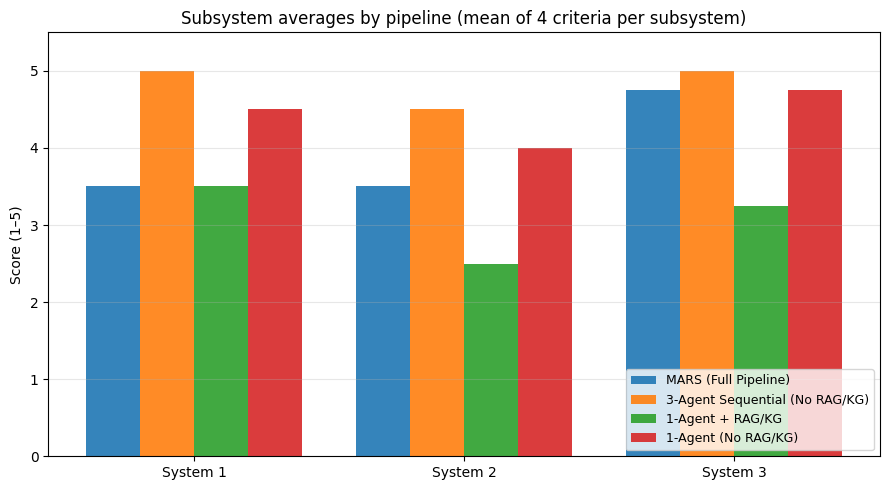

In [8]:
def subsystem_avg(ck: str, keys: list[str]) -> float | None:
    xs = [dim_score(ck, k) for k in keys]
    if any(x is None for x in xs):
        return None
    return float(np.mean(xs))


cluster_labels = ["System 1", "System 2", "System 3"]
key_groups = (SYS1_KEYS, SYS2_KEYS, SYS3_KEYS)
n_groups = len(key_groups)
n_cond = len(present_keys)
x = np.arange(n_groups, dtype=float)
width = 0.8 / n_cond

fig, ax = plt.subplots(figsize=(9, 5))
for i, ck in enumerate(present_keys):
    heights = [subsystem_avg(ck, kg) for kg in key_groups]
    heights = [np.nan if h is None else h for h in heights]
    pos = x - 0.4 + width / 2 + i * width
    ax.bar(
        pos,
        heights,
        width,
        label=condition_label(ck),
        color=colors_ordered[i],
        alpha=0.9,
    )

ax.set_xticks(x)
ax.set_xticklabels(cluster_labels)
ax.set_ylabel("Score (1–5)")
ax.set_ylim(0, 5.5)
ax.set_title("Subsystem averages by pipeline (mean of 4 criteria per subsystem)")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Grouped bar charts — each **subsystem** (Systems 1–3)

Within each subsystem, bars compare the **four pipelines** on each criterion.

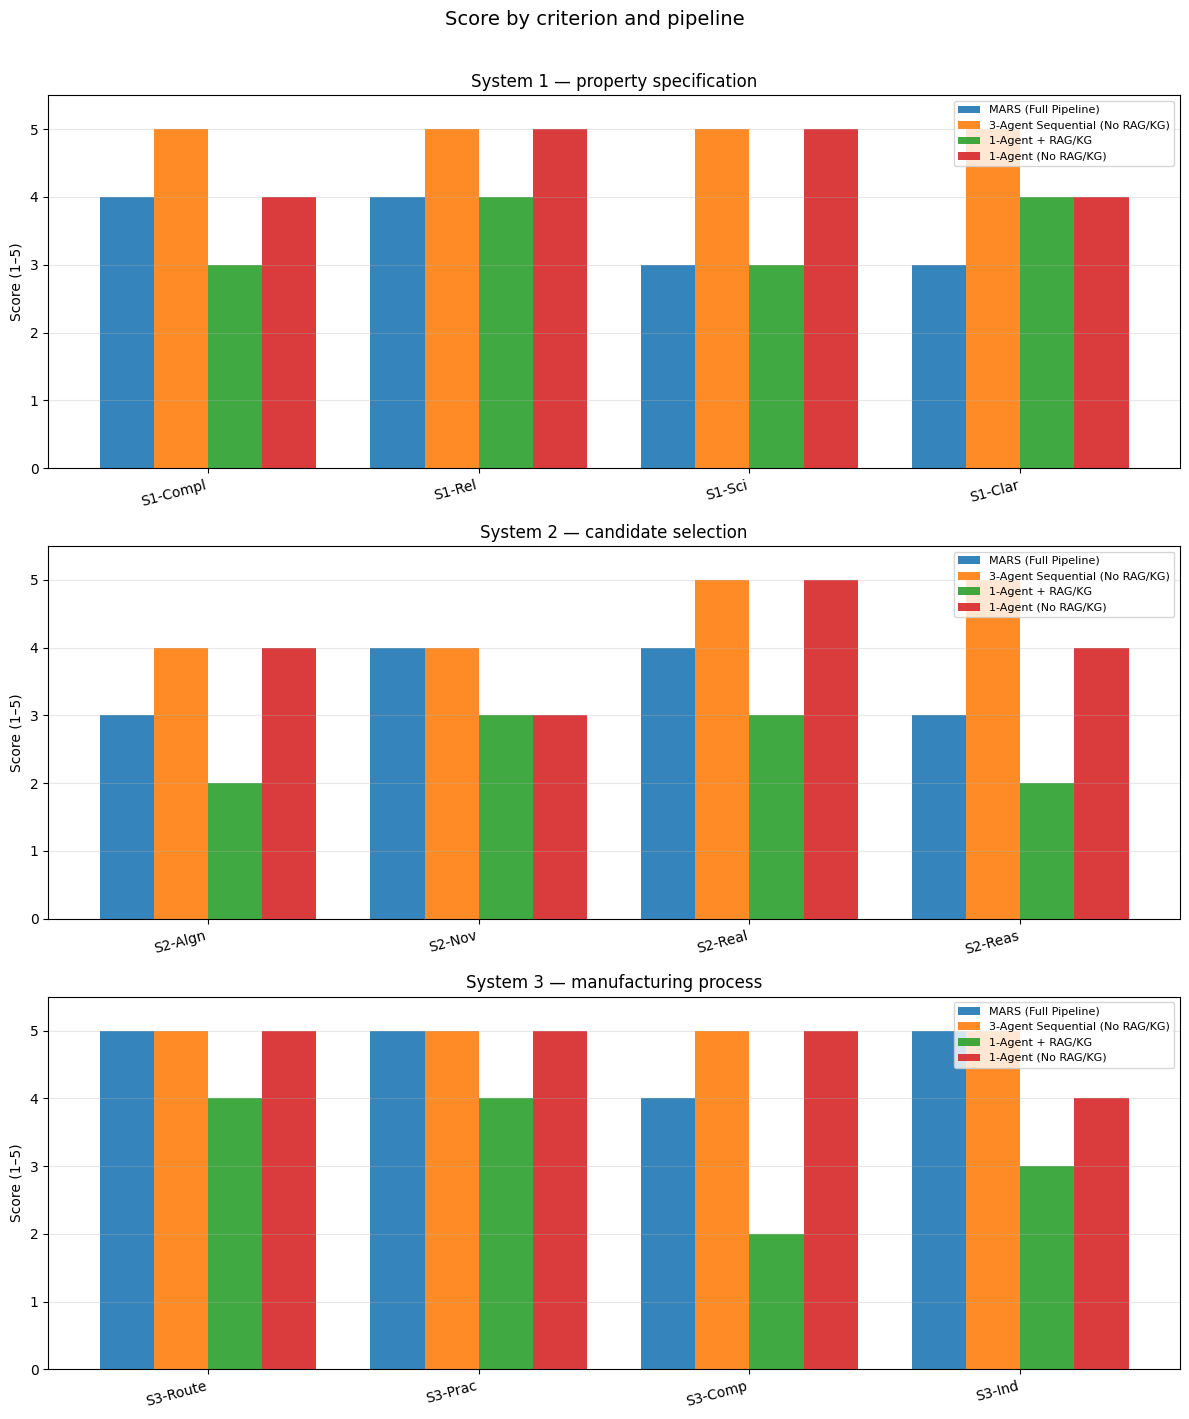

In [9]:
def grouped_bars_subsystem(ax, dim_keys: list[str], title: str) -> None:
    n_c = len(dim_keys)
    n_cond = len(present_keys)
    x = np.arange(n_c)
    width = 0.8 / n_cond
    for i, ck in enumerate(present_keys):
        scores = []
        for dk in dim_keys:
            v = dim_score(ck, dk)
            scores.append(np.nan if v is None else v)
        pos = x - 0.4 + width / 2 + i * width
        ax.bar(
            pos,
            scores,
            width,
            label=condition_label(ck),
            color=colors_ordered[i],
            alpha=0.9,
        )
    ax.set_xticks(x)
    ax.set_xticklabels([short_label(k) for k in dim_keys], rotation=15, ha="right")
    ax.set_ylabel("Score (1–5)")
    ax.set_ylim(0, 5.5)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")


fig, axes = plt.subplots(3, 1, figsize=(12, 14))
grouped_bars_subsystem(axes[0], SYS1_KEYS, "System 1 — property specification")
grouped_bars_subsystem(axes[1], SYS2_KEYS, "System 2 — candidate selection")
grouped_bars_subsystem(axes[2], SYS3_KEYS, "System 3 — manufacturing process")
plt.suptitle("Score by criterion and pipeline", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Bar charts — each **pipeline** (all 12 categories)

Four panels: one bar chart per pipeline with every rubric dimension.

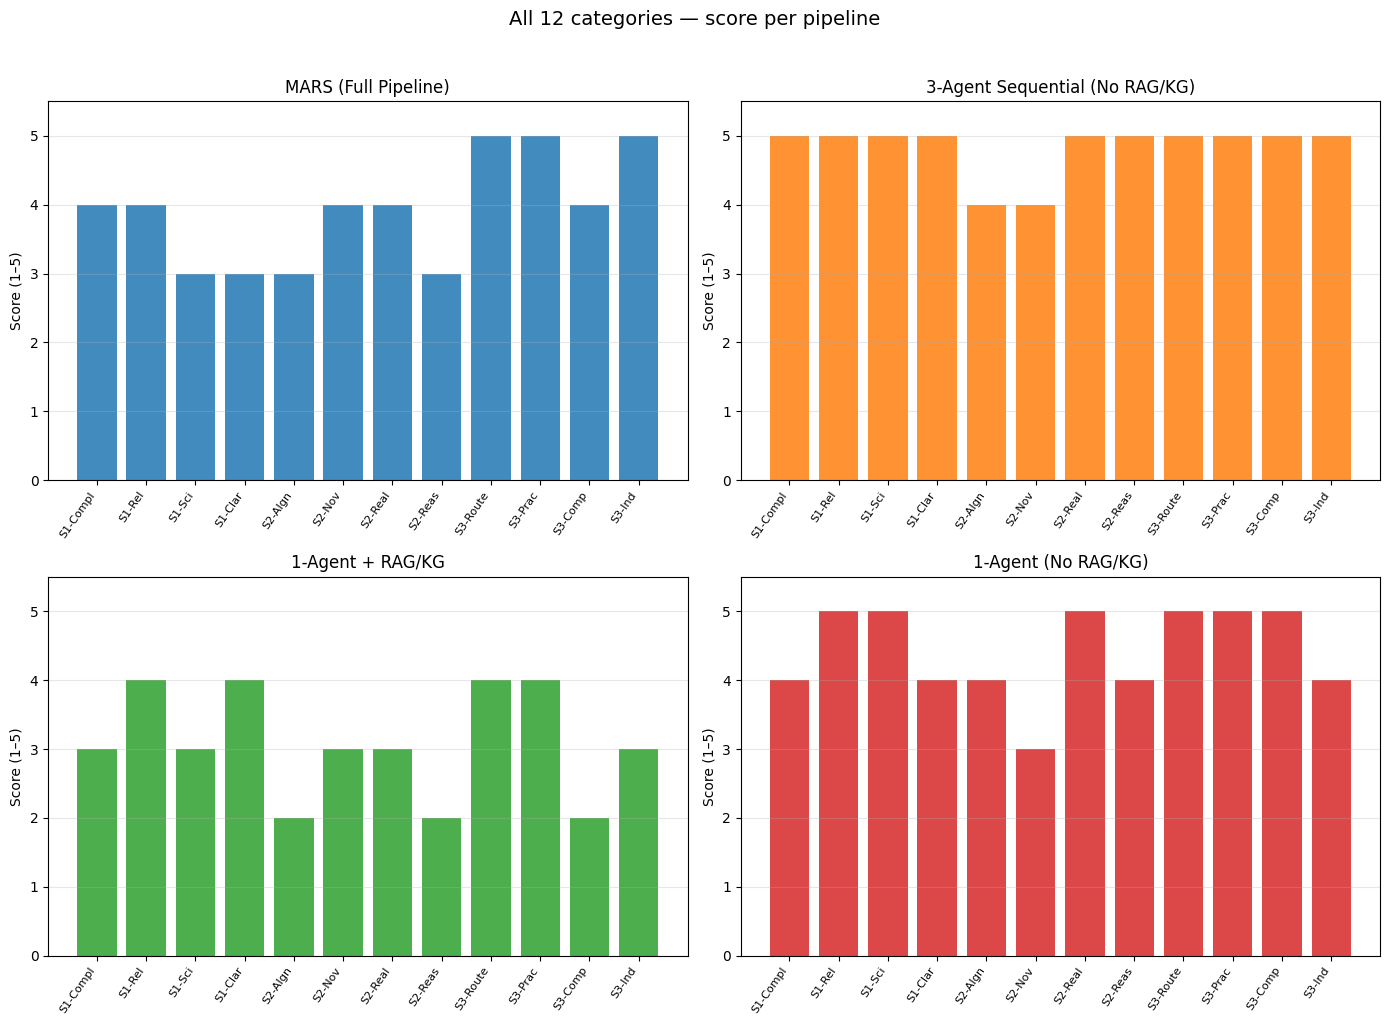

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, ck in enumerate(present_keys):
    ax = axes[idx]
    scores = []
    for dk in ALL_DIM_KEYS:
        v = dim_score(ck, dk)
        scores.append(np.nan if v is None else v)
    x = np.arange(len(ALL_DIM_KEYS))
    ax.bar(
        x,
        scores,
        color=colors_ordered[idx],
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([short_label(k) for k in ALL_DIM_KEYS], rotation=55, ha="right", fontsize=8)
    ax.set_ylabel("Score (1–5)")
    ax.set_ylim(0, 5.5)
    ax.set_title(condition_label(ck))
    ax.grid(axis="y", alpha=0.3)

for j in range(len(present_keys), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("All 12 categories — score per pipeline", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Heatmap & ranks

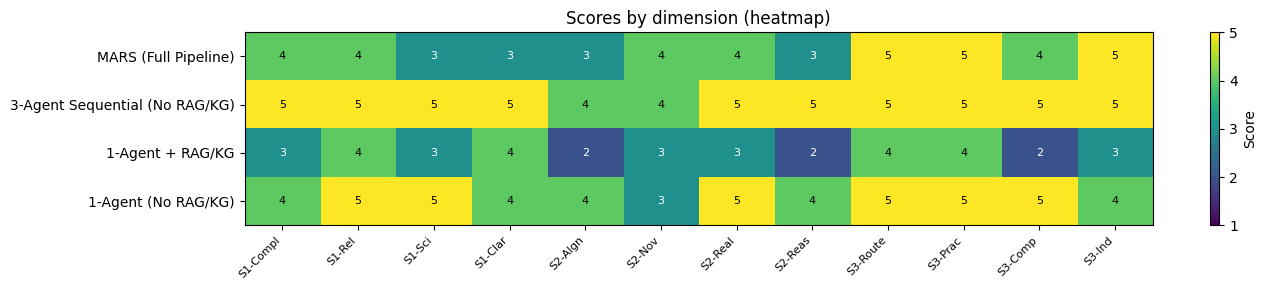

In [11]:
dim_rows = []
for ck in present_keys:
    block = conditions.get(ck) or {}
    label = block.get("label", ck)
    for k, v in block.items():
        if k in ("label", "weighted_avg"):
            continue
        if isinstance(v, (int, float)):
            dim_rows.append({"label": label, "dimension": k, "score": float(v)})

df_dims = pd.DataFrame(dim_rows)
if df_dims.empty:
    print("No per-dimension scores in aggregate.")
else:
    pivot = df_dims.pivot(index="label", columns="dimension", values="score")
    pivot = pivot.reindex(index=labels_ordered, columns=ALL_DIM_KEYS)
    fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.55)))
    arr = pivot.to_numpy()
    im = ax.imshow(arr, aspect="auto", vmin=1, vmax=5, cmap="viridis")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([short_label(c) for c in pivot.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", color="white" if val < 3.5 else "black", fontsize=8)
    ax.set_title("Scores by dimension (heatmap)")
    plt.colorbar(im, ax=ax, label="Score")
    plt.tight_layout()
    plt.show()

In [12]:
rank_rows = []
for ck in present_keys:
    r = ranks.get(ck)
    if not isinstance(r, (int, float)):
        continue
    rank_rows.append({"label": condition_label(ck), "rank": float(r)})
df_ranks = pd.DataFrame(rank_rows).sort_values("rank")
df_ranks

,label,rank
1,3-Agent Sequential (No RAG/KG),1.0
3,1-Agent (No RAG/KG),2.0
0,MARS (Full Pipeline),3.0
2,1-Agent + RAG/KG,4.0


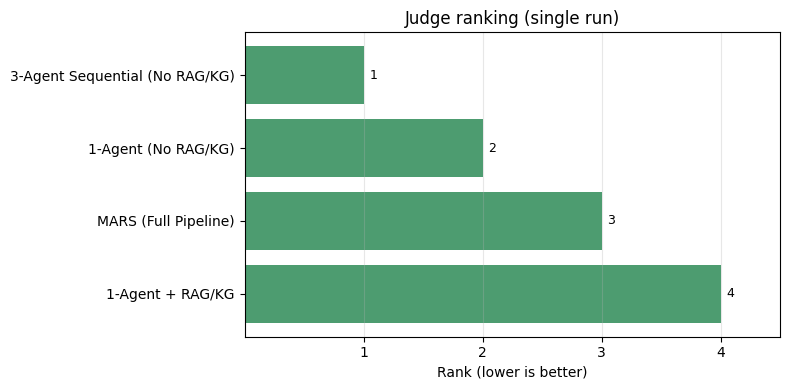

In [13]:
if not df_ranks.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    y = np.arange(len(df_ranks))[::-1]
    ax.barh(
        y,
        df_ranks["rank"],
        color="seagreen",
        alpha=0.85,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(df_ranks["label"])
    ax.set_xlabel("Rank (lower is better)")
    ax.set_xlim(0, len(df_ranks) + 0.5)
    ax.set_xticks(np.arange(1, len(df_ranks) + 1))
    ax.set_title("Judge ranking (single run)")
    ax.grid(axis="x", alpha=0.3)
    for yi, r in zip(y, df_ranks["rank"].to_numpy()):
        ax.text(r + 0.05, yi, f"{r:.0f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

## Judge reasoning

For each query, the per-criterion reasoning the judge wrote when assigning each score, plus the overall ranking rationale. Useful as paper-appendix material.

In [14]:
reason_rows = []
for q in per_query:
    qname = q.get("query_name", "?")
    q_scores = q.get("scores") or {}
    for ck in present_keys:
        block = q_scores.get(ck) or {}
        label = condition_label(ck)
        for dk in ALL_DIM_KEYS:
            cell = block.get(dk)
            if isinstance(cell, dict):
                reason_rows.append(
                    {
                        "query": qname,
                        "pipeline": label,
                        "criterion": short_label(dk),
                        "score": cell.get("score"),
                        "reasoning": cell.get("reasoning", ""),
                    }
                )

df_reasons = pd.DataFrame(reason_rows)
pd.set_option("display.max_colwidth", None)
df_reasons

,query,pipeline,criterion,score,reasoning
0,Query1,MARS (Full Pipeline),S1-Compl,4,"Covers most relevant categories, but some requirements are vague or redundant (e.g., 'fluorinated elastomer backbone' conflicts with PFAS-free constraint)."
1,Query1,MARS (Full Pipeline),S1-Rel,4,"Most requirements are relevant, but some (e.g., recyclability, PET stream contamination) are tangential to the core substitution task."
2,Query1,MARS (Full Pipeline),S1-Sci,3,"There are scientific inconsistencies: 'fluorinated elastomer backbone' is incompatible with PFAS-free, and some property targets (e.g., Tg >200°C for an elastomer) are unrealistic."
3,Query1,MARS (Full Pipeline),S1-Clar,3,"The list is long but mixes properties, constraints, and process notes; some terms are ambiguous or lack units, making testability difficult."
4,Query1,MARS (Full Pipeline),S2-Algn,3,"The PA/POE blend meets some requirements (chemical resistance, flexibility), but polyamides are not truly transparent and may not meet the strictest gas barrier or optical criteria."
5,Query1,MARS (Full Pipeline),S2-Nov,4,"The blend is a creative, non-obvious approach leveraging compatibilization, not a default commodity pick."
6,Query1,MARS (Full Pipeline),S2-Real,4,"All components are real and commercially available, and the blend is plausible, though some property claims (optical clarity, high Tg with flexibility) are optimistic."
7,Query1,MARS (Full Pipeline),S2-Reas,3,"Justification is detailed but overstates the blend's ability to meet all requirements, especially transparency and high flexibility at high Tg."
8,Query1,MARS (Full Pipeline),S3-Route,5,The compounding and extrusion process is standard and causally coherent for such blends.
9,Query1,MARS (Full Pipeline),S3-Prac,5,Processing parameters are realistic and well-specified for lab or pilot scale.


In [15]:
# Overall ranking rationale per query
for q in per_query:
    qname = q.get("query_name", "?")
    ranking = q.get("ranking") or []
    reason = q.get("ranking_reasoning", "")
    ordered_labels = [condition_label(ck) for ck in ranking]
    print(f"=== {qname} ===")
    print("Ranking (best → worst):")
    for i, lab in enumerate(ordered_labels, 1):
        print(f"  {i}. {lab}")
    print("\nRationale:")
    print(reason)
    print()

=== Query1 ===
Ranking (best → worst):
  1. 3-Agent Sequential (No RAG/KG)
  2. 1-Agent (No RAG/KG)
  3. MARS (Full Pipeline)
  4. 1-Agent + RAG/KG

Rationale:
System A is the most thorough, technically sound, and operationally detailed, with only minor tradeoffs. System D is also strong, but slightly less detailed and novel. System B is creative but suffers from scientific inconsistencies and over-optimistic property claims. System C fundamentally misidentifies PEI as an elastomer, leading to a critical mismatch with the application's flexibility requirements.

